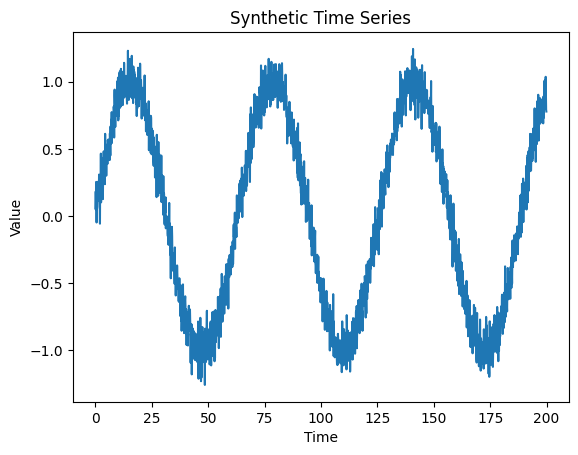

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)
t = np.arange(0, 200, 0.1)
data = np.sin(0.1 * t) + 0.1 * np.random.randn(len(t))
plt.plot(t, data)
plt.title("Synthetic Time Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

In [2]:
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)
window_size = 20
X, y = create_sequences(data, window_size)
# reshape for RNN: (samples, timesteps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

In [3]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(1584, 20, 1) (396, 20, 1)
(1584,) (396,)


In [4]:
from tensorflow import keras
from tensorflow.keras import layers

model_mlp = keras.Sequential([
    layers.Flatten(input_shape=(window_size,1)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

model_mlp.summary()
model_mlp.compile(optimizer='adam', loss='mse')

history_mlp = model_mlp.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.2
)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 20)                0         
                                                                 
 dense (Dense)               (None, 32)                672       
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 705
Trainable params: 705
Non-trainable params: 0
_________________________________________________________________
Epoch 1/10
40/40 [==============================] - 1s 13ms/step - loss: 0.0309 - val_loss: 0.0205
Epoch 2/10
40/40 [==============================] - 0s 4ms/step - loss: 0.0219 - val_loss: 0.0200
Epoch 3/10
40/40 [==============================] - 0s 3ms/step - loss: 0.0208 - val_loss: 0.0180
Epoch 4/10
40/40 [=========

In [5]:
model_lstm = keras.Sequential([
    layers.LSTM(32, input_shape=(window_size,1)),
    layers.Dense(1)
])

model_lstm.summary()
model_lstm.compile(optimizer='adam', loss='mse')

history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.2
)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 32)                4352      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 4,385
Trainable params: 4,385
Non-trainable params: 0
_________________________________________________________________
Epoch 1/10
40/40 [==============================] - 4s 33ms/step - loss: 0.2138 - val_loss: 0.0242
Epoch 2/10
40/40 [==============================] - 1s 14ms/step - loss: 0.0190 - val_loss: 0.0151
Epoch 3/10
40/40 [==============================] - 1s 16ms/step - loss: 0.0155 - val_loss: 0.0151
Epoch 4/10
40/40 [==============================] - 0s 10ms/step - loss: 0.0143 - val_loss: 0.0141
Epoch 5/10
40/40 [==============================] - 

In [6]:
model_gru = keras.Sequential([
    layers.GRU(32, input_shape=(window_size,1)),
    layers.Dense(1)
])

model_gru.summary()
model_gru.compile(optimizer='adam', loss='mse')

history_gru = model_gru.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.2
)

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 32)                3360      
                                                                 
 dense_3 (Dense)             (None, 1)                 33        
                                                                 
Total params: 3,393
Trainable params: 3,393
Non-trainable params: 0
_________________________________________________________________
Epoch 1/10
40/40 [==============================] - 4s 30ms/step - loss: 0.1057 - val_loss: 0.0196
Epoch 2/10
40/40 [==============================] - 1s 18ms/step - loss: 0.0124 - val_loss: 0.0120
Epoch 3/10
40/40 [==============================] - 0s 12ms/step - loss: 0.0120 - val_loss: 0.0113
Epoch 4/10
40/40 [==============================] - 1s 16ms/step - loss: 0.0120 - val_loss: 0.0114
Epoch 5/10
40/40 [==============================] - 

In [7]:
import numpy as np

def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mse = np.mean((y_test - y_pred.flatten())**2)
    return mse
print("MLP MSE:", evaluate(model_mlp, X_test, y_test))
print("LSTM MSE:", evaluate(model_lstm, X_test, y_test))
print("GRU MSE:", evaluate(model_gru, X_test, y_test))

13/13 [==============================] - 0s 3ms/step
MLP MSE: 0.016458287253783847
13/13 [==============================] - 1s 8ms/step
LSTM MSE: 0.011990410182978853
13/13 [==============================] - 1s 3ms/step
GRU MSE: 0.01173235068252368


13/13 [==============================] - 0s 4ms/step


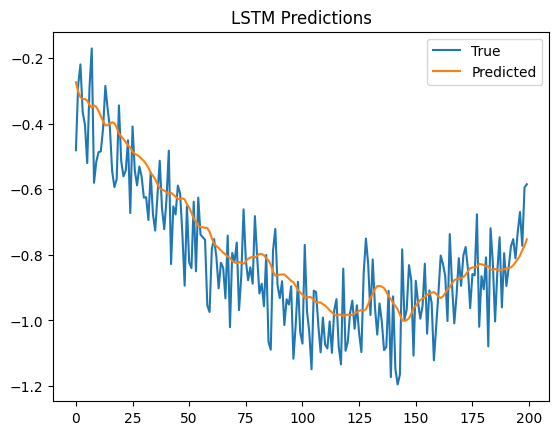

In [8]:
y_pred = model_lstm.predict(X_test)
plt.plot(y_test[:200], label="True")
plt.plot(y_pred[:200], label="Predicted")
plt.legend()
plt.title("LSTM Predictions")
plt.show()